In [5]:
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

In [6]:
# ── VARIABLES ────────────────────────────────────────────────
df  = pd.read_csv('sheets/A2142_gaussian.csv')
timesc_df = pd.read_csv('sheets/timesc.csv')
ra  = df["WEAVE_RA"].values
dec = df["WEAVE_DEC"].values
z   = df["Z_FINAL"].values

# Cosmological parameters (Einasto et al. 2015)
H0  = 100.0
h   = H0 / 100   # = 1.0
Om0 = 0.27
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

# Cluster centre: Abell 2142 (Gr3070, Tempel et al. 2014b)
RA_CENTRE       = 239.52
DEC_CENTRE      = 27.32
Z_CENTRE        = 0.0888
FILAMENT_PA_DEG = 63.0    # PA = 63° CCW from west, where west = left = +RA direction
# CCW from left goes downward toward south

In [7]:
# ── COMOVING DISTANCE ─────────────────────────────────────────────────────

def comoving_distance(z):
    """Comoving distance in h^-1 Mpc."""
    d_Mpc = cosmo.comoving_distance(z).to(u.Mpc).value
    return d_Mpc * h   # h = 1.0, so d [h^-1 Mpc] = d [Mpc]

# ── CARTESIAN PROJECTION ──────────────────────────────────────────────────

def to_cartesian(ra_deg, dec_deg, d_comov):
    ra  = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    x =  d_comov * np.cos(dec) * np.cos(ra)
    y =  d_comov * np.cos(dec) * np.sin(ra)
    z =  d_comov * np.sin(dec)
    return x, y, z
    
# ── FILAMENT AXIS ─────────────────────────────────────────────────────────

def build_filament_axis(ra_c, dec_c, z_c, pa_deg):
    d_c = comoving_distance(z_c)                          # get comoving distance to the cluster centre    
    xc, yc, zc = to_cartesian(ra_c, dec_c, d_c)           # convert the cluster centre (RA, Dec, d_c) into 3D Cartesian coordinates
    centre = np.array([xc, yc, zc])                       # store the cluster centre as a 3D position vector in h^-1 Mpc
    ra_r, dec_r = np.radians(ra_c), np.radians(dec_c)     # convert ra and dec of the galaxies into radians
    
    # west points left from the cluster center
    west_hat  = np.array([-np.cos(dec_r) * np.sin(ra_r),  # the unit vector that points west at the cluster centre
                           np.cos(dec_r) * np.cos(ra_r),  # This is the partial derivative of the Cartesian position vector with respect to RA,
                           0.0])                          # evaluated at (RA_c, Dec_c)                                         
    west_hat /= np.linalg.norm(west_hat)                  # normalize to unit length
    
    # north points up from the cluster center
    north_hat = np.array([-np.sin(dec_r) * np.cos(ra_r),  # the unit vector pointing north (+Dec direction) at the cluster centre
                          -np.sin(dec_r) * np.sin(ra_r),  
                           np.cos(dec_r)])
    north_hat /= np.linalg.norm(north_hat)                # normalize to unit length
    pa_rad = np.radians(pa_deg)                           # convery position angle degrees -> radians
    # construct filament direction vector
    filament_hat = np.cos(pa_rad) * west_hat - np.sin(pa_rad) * north_hat  # cos(63) * west - sin(63) * north
    filament_hat /= np.linalg.norm(filament_hat)
    return centre, filament_hat

# ── DISTANCE CALCULATIONS ─────────────────────────────────────────────────

def filament_distances(pos, centre, filament_hat):
    delta   = pos - centre
    D_along = delta @ filament_hat
    perp    = delta - np.outer(D_along, filament_hat)
    D_fil   = np.linalg.norm(perp, axis=1)
    return D_along, D_fil

In [8]:
# ── RUN ───────────────────────────────────────────────────────────────────

print(f"Loaded {len(df)} galaxies\n")
print(f"Comoving Distance at Cluster Centre: {comoving_distance(Z_CENTRE)} [h^-1 Mpc]")
d_comov = comoving_distance(z)
x, y, z_cart = to_cartesian(ra, dec, d_comov)

centre, filament_hat = build_filament_axis(RA_CENTRE, DEC_CENTRE, Z_CENTRE, FILAMENT_PA_DEG)
#filament_hat = -filament_hat

pos = np.column_stack([x, y, z_cart])
D_along, D_fil = filament_distances(pos, centre, filament_hat)
is_mem = D_fil <= 7

# Attach results back to dataframe (all in units h^-1 Mpc)
df["D_along"] = D_along
df["D_fil"]   = D_fil

df = df.merge(timesc_df, left_on='NSPEC', right_on='nspec', how='left').drop(columns=['NSPEC'])

df.to_csv('Gauss_dist_timesc.csv', index=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Filament axis unit vector : {np.round(filament_hat, 4)}")
print("\n── First 10 galaxies ────────────────────────────────────────────")
display(df[['WEAVE_RA', 'WEAVE_DEC', 'Z_FINAL', "D_fil", "D_along"]].head(10).round(4))

Loaded 175 galaxies

Comoving Distance at Cluster Centre: 260.4602663602367 [h^-1 Mpc]
Filament axis unit vector : [ 0.1838 -0.5827 -0.7916]

── First 10 galaxies ────────────────────────────────────────────


,WEAVE_RA,WEAVE_DEC,Z_FINAL,D_fil,D_along
0,239.4519,26.5165,0.0902,5.3108,3.1884
1,239.5913,26.4330,0.0855,8.9050,3.5992
2,239.9890,26.1963,0.0862,6.8350,5.2760
3,239.4771,26.5575,0.0876,3.1433,2.9789
4,239.6885,26.5764,0.0873,3.7365,3.2764
5,239.7066,26.3754,0.0866,5.7687,4.0809
6,240.0017,26.0657,0.0906,6.0267,6.1079
7,239.4487,26.6331,0.0864,6.3532,2.5883
8,239.5449,26.7026,0.0923,10.9415,2.6529
9,239.5837,26.5278,0.0883,1.5377,3.3183


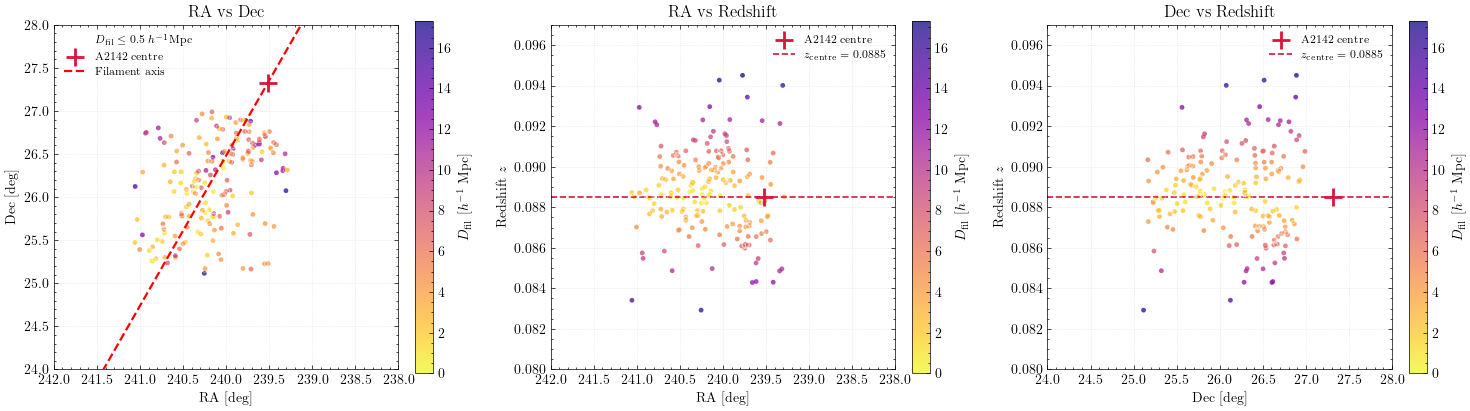

In [9]:
# ── Plot: 2D projections coloured by D_fil ───────────────────────────────────

pa_rad  = np.radians(FILAMENT_PA_DEG)
cos_dec = np.cos(np.radians(DEC_CENTRE))

t_deg    = np.linspace(-5, 5, 500)
ra_line  = RA_CENTRE  - t_deg * np.cos(pa_rad) / cos_dec
dec_line = DEC_CENTRE + t_deg * np.sin(pa_rad)

scatter_kw = dict(cmap='plasma_r', vmin=0, s=12, alpha=0.75,
                  linewidths=0, rasterized=True)

RA_MIN, RA_MAX = 238, 242
DEC_MIN, DEC_MAX = 24, 28
Z_MIN, Z_MAX = 0.08, 0.097

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Left: RA vs Dec ───────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(ra, dec, c=D_fil, **scatter_kw)
ax.scatter(ra[is_mem], dec[is_mem], facecolors='none', edgecolors='white',
           s=28, lw=0.5, alpha=0.6, zorder=4,
           label=r'$D_\mathrm{fil} \leq 0.5\ h^{-1}$Mpc')
ax.scatter(RA_CENTRE, DEC_CENTRE, color='crimson', s=180, marker='+',
           lw=2, zorder=6, label='A2142 centre')
ax.plot(ra_line, dec_line, 'r--', lw=1.6, zorder=5, label='Filament axis')
fig.colorbar(sc, ax=ax, label=r'$D_\mathrm{fil}\ [h^{-1}\ \mathrm{Mpc}]$', shrink=0.75, pad=0.04)
ax.set_xlim(RA_MAX, RA_MIN)   # inverted
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('RA vs Dec')
ax.set_box_aspect(1)
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.4)

# ── Middle: RA vs redshift ────────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(ra, z, c=D_fil, **scatter_kw)
ax.scatter(ra[is_mem], z[is_mem], facecolors='none', edgecolors='white',
           s=28, lw=0.5, alpha=0.6, zorder=4)
ax.scatter(RA_CENTRE, Z_CENTRE, color='crimson', s=180, marker='+',
           lw=2, zorder=6, label='A2142 centre')
ax.axhline(Z_CENTRE, color='crimson', lw=1.2, ls='--',
           label=f'$z_{{\\rm centre}}={Z_CENTRE}$')
fig.colorbar(sc, ax=ax, label=r'$D_\mathrm{fil}\ [h^{-1}\ \mathrm{Mpc}]$', shrink=0.75, pad=0.04)
ax.set_xlim(RA_MAX, RA_MIN)
ax.set_ylim(Z_MIN, Z_MAX)
ax.set_xlabel('RA [deg]')
ax.set_ylabel(r'Redshift $z$')
ax.set_title('RA vs Redshift')
ax.set_box_aspect(1)
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.4)

# ── Right: Dec vs redshift ────────────────────────────────────────────────────
ax = axes[2]
sc = ax.scatter(dec, z, c=D_fil, **scatter_kw)
ax.scatter(dec[is_mem], z[is_mem], facecolors='none', edgecolors='white',
           s=28, lw=0.5, alpha=0.6, zorder=4)
ax.scatter(DEC_CENTRE, Z_CENTRE, color='crimson', s=180, marker='+',
           lw=2, zorder=6, label='A2142 centre')
ax.axhline(Z_CENTRE, color='crimson', lw=1.2, ls='--',
           label=f'$z_{{\\rm centre}}={Z_CENTRE}$')
fig.colorbar(sc, ax=ax, label=r'$D_\mathrm{fil}\ [h^{-1}\ \mathrm{Mpc}]$', shrink=0.75, pad=0.04)
ax.set_xlim(DEC_MIN, DEC_MAX)
ax.set_ylim(Z_MIN, Z_MAX)
ax.set_xlabel('Dec [deg]')
ax.set_ylabel(r'Redshift $z$')
ax.set_title('Dec vs Redshift')
ax.set_box_aspect(1)
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/filament_radecz.pdf', bbox_inches='tight')
plt.show()

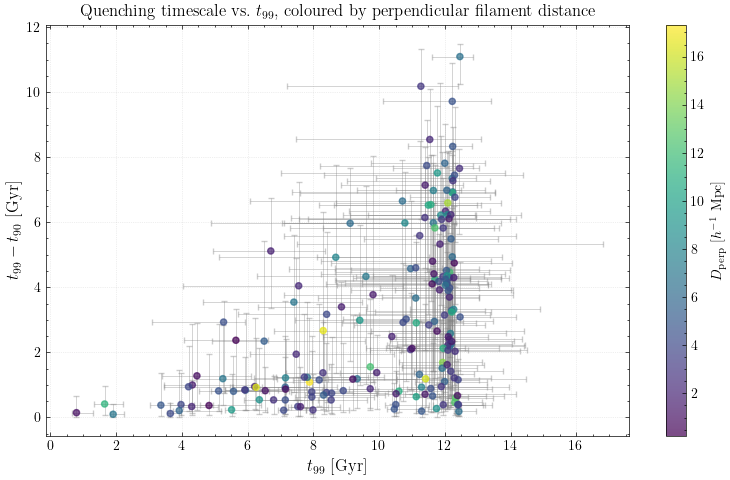

In [13]:
t99    = df['t99'].values
delta_t = df['timesc'].values
dist   = df['D_fil'].values

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(t99, delta_t, c=dist, cmap='viridis', s=20, alpha=0.7, zorder=3)
ax.errorbar(t99, delta_t,
            xerr=[df['err_lo_t99'].values, df['err_hi_t99'].values],
            yerr=[df['err_lo'].values, df['err_hi'].values],
            fmt='none', color='grey', alpha=0.4, lw=0.6, capsize=2, zorder=2)

plt.colorbar(sc, ax=ax, label=r'$D_\mathrm{perp}\ [h^{-1}\ \mathrm{Mpc}]$')

ax.set_xlabel(r'$t_{99}$ [Gyr]', fontsize=12)
ax.set_ylabel(r'$t_{99} - t_{90}$ [Gyr]', fontsize=12)
ax.set_title(r'Quenching timescale vs.\ $t_{99}$, coloured by perpendicular filament distance', fontsize=12)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/delta_t_vs_t99.pdf', bbox_inches='tight')
plt.show()

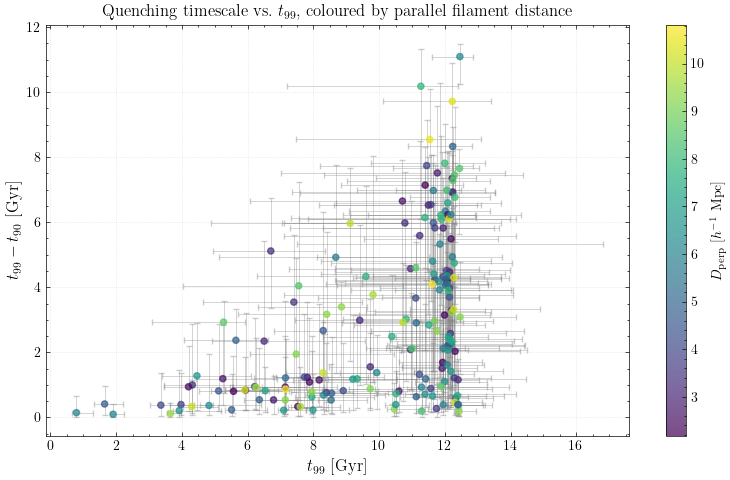

In [14]:
t99    = df['t99'].values
delta_t = df['timesc'].values
dist   = df['D_along'].values

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(t99, delta_t, c=dist, cmap='viridis', s=20, alpha=0.7, zorder=3)
ax.errorbar(t99, delta_t,
            xerr=[df['err_lo_t99'].values, df['err_hi_t99'].values],
            yerr=[df['err_lo'].values, df['err_hi'].values],
            fmt='none', color='grey', alpha=0.4, lw=0.6, capsize=2, zorder=2)

plt.colorbar(sc, ax=ax, label=r'$D_\mathrm{perp}\ [h^{-1}\ \mathrm{Mpc}]$')

ax.set_xlabel(r'$t_{99}$ [Gyr]', fontsize=12)
ax.set_ylabel(r'$t_{99} - t_{90}$ [Gyr]', fontsize=12)
ax.set_title(r'Quenching timescale vs.\ $t_{99}$, coloured by parallel filament distance', fontsize=12)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/delta_t_vs_t99.pdf', bbox_inches='tight')
plt.show()